# Load Dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "FareedKhan/1k_stories_100_genre"
)

dataset

d:\work\cyshield_Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\work\cyshield_Task\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shawk\.cache\huggingface\hub\datasets--FareedKhan--1k_stories_100_genre. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate develope

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'story', 'genre'],
        num_rows: 1000
    })
})

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'story', 'genre'],
        num_rows: 1000
    })
})

In [10]:
train = dataset["train"]

In [11]:
print(train)
print(train.column_names)

Dataset({
    features: ['id', 'title', 'story', 'genre'],
    num_rows: 1000
})
['id', 'title', 'story', 'genre']


# Basic Inspection

In [7]:
len(train)

1000

In [8]:
train[0]

{'id': 457580,
 'title': 'The Chronicles of the Cosmic Rift',
 'story': 'In the year 2250, Earth had made significant strides in space exploration and interstellar travel. The United Earth Government (UEG) had established colonies on Mars, Jupiter\'s moon Europa, and Saturn\'s moon Titan. The advancements in technology and science had led to the creation of the Cosmic Rift Exploration Agency (CREA), a government-funded organization tasked with exploring the unknown regions of space and discovering new worlds and resources.\n\n    Dr. Amelia Hart, a brilliant astrophysicist, was the lead scientist at CREA\'s headquarters on Luna. She had devoted her entire life to understanding the mysteries of the universe and had become a pioneer in her field. She was determined to uncover the secrets of the cosmic rifts, a series of mysterious and seemingly unconnected energy anomalies that had started appearing throughout the galaxy.\n\n    Dr. Hart assembled a diverse team of experts for her next m

In [12]:
import pandas as pd

df = train.to_pandas()


In [13]:
df.head()

,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1000 non-null   int64
 1   title   1000 non-null   str  
 2   story   1000 non-null   str  
 3   genre   1000 non-null   str  
dtypes: int64(1), str(3)
memory usage: 5.7 MB


In [15]:
df.describe(include="all")

,id,title,story,genre
count,1000.000000,1000,1000,1000
unique,NaN,1000,1000,99
top,NaN,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Historical Adventure
freq,NaN,1,1,20
mean,510649.151000,NaN,NaN,NaN
std,290220.281546,NaN,NaN,NaN
min,1328.000000,NaN,NaN,NaN
25%,253966.750000,NaN,NaN,NaN
50%,522381.000000,NaN,NaN,NaN
75%,769093.250000,NaN,NaN,NaN


In [16]:
df.isna().sum()

id       0
title    0
story    0
genre    0
dtype: int64

In [17]:
df["id"].duplicated().sum()

np.int64(0)

In [18]:
df["title"].duplicated().sum()

np.int64(0)

In [19]:
df["story"].duplicated().sum()

np.int64(0)

In [20]:
(df["story"].str.strip() == "").sum()

np.int64(0)

In [21]:
df["genre"].nunique()

99

In [22]:
df["genre"].value_counts()

genre
Historical Adventure    20
Science Fiction         10
Fantasy                 10
Mystery                 10
Thriller                10
                        ..
Space Exploration       10
Steampunk Fantasy       10
Noir Comedy             10
Social Commentary       10
Techno-Mystery          10
Name: count, Length: 99, dtype: int64

# Story Length Analysis

In [23]:
df["word_count"] = df["story"].str.split().str.len()
df["char_count"] = df["story"].str.len()

In [24]:
df["word_count"].describe()

count    1000.000000
mean      985.861000
std       430.611272
min        83.000000
25%       804.000000
50%       978.500000
75%      1163.500000
max      3093.000000
Name: word_count, dtype: float64

C:\Users\shawk\AppData\Local\Temp\ipykernel_13136\2406153840.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


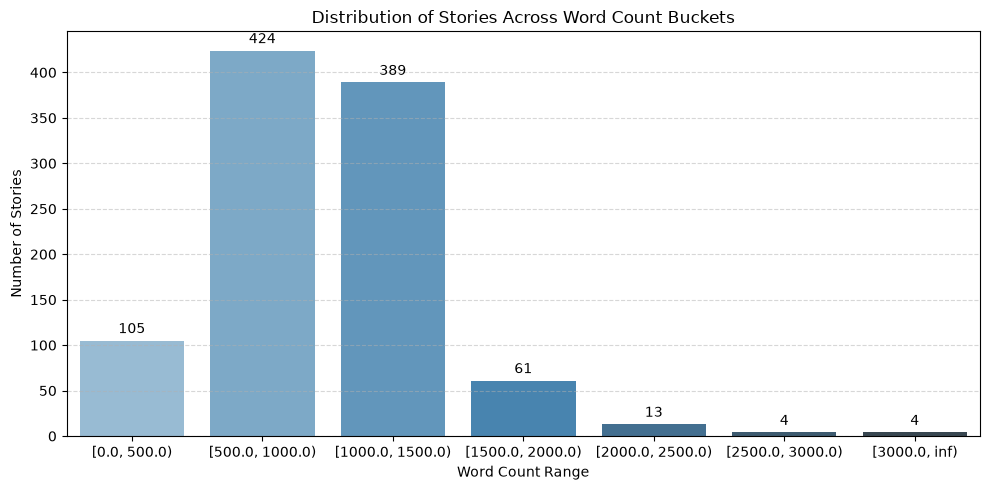

In [42]:
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, float("inf")]

df["length_bucket"] = pd.cut(
    df["word_count"],
    bins=bins,
    right=False
)

bucket_counts = (
    df["length_bucket"]
    .value_counts()
    .sort_index()
    .reset_index(name="count")
)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=bucket_counts,
    x="length_bucket",
    y="count",
    palette="Blues_d",
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.title("Distribution of Stories Across Word Count Buckets")
plt.xlabel("Word Count Range")
plt.ylabel("Number of Stories")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [43]:
bucket_counts

,length_bucket,count
0,"[0.0, 500.0)",105
1,"[500.0, 1000.0)",424
2,"[1000.0, 1500.0)",389
3,"[1500.0, 2000.0)",61
4,"[2000.0, 2500.0)",13
5,"[2500.0, 3000.0)",4
6,"[3000.0, inf)",4


In [25]:
df["word_count"].quantile(
    [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

0.25     804.0
0.50     978.5
0.75    1163.5
0.90    1424.6
0.95    1669.3
0.99    2268.5
Name: word_count, dtype: float64

# Genre Distribution

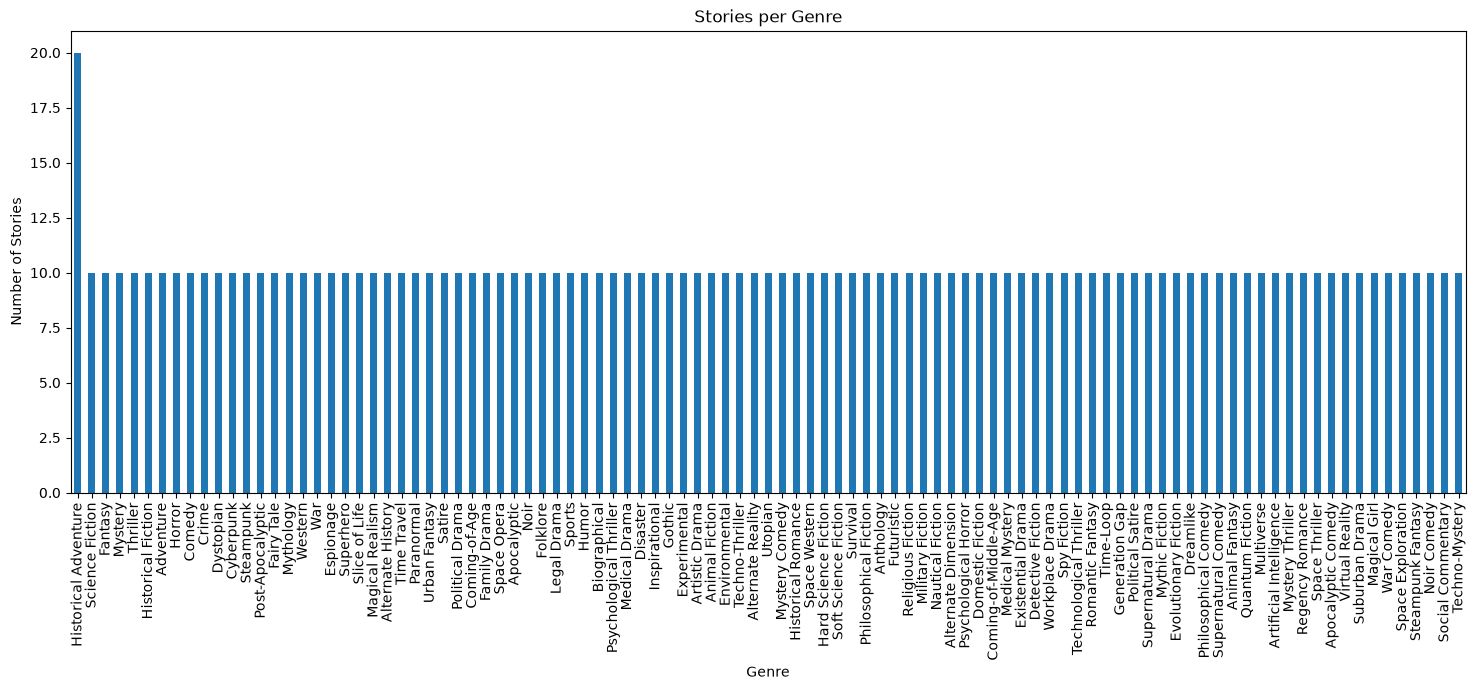

In [26]:
import matplotlib.pyplot as plt

genre_counts = df["genre"].value_counts()

genre_counts.plot(kind="bar", figsize=(18, 6))

plt.title("Stories per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Stories")
plt.xticks(rotation=90)
plt.show()

# Story Length vs Genre

In [30]:
df.head()

,id,title,story,genre,word_count,char_count
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction,1309,8133
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy,1081,6361
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery,774,4683
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure,844,5018
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller,1091,6709


In [28]:
genre_length = (
    df.groupby("genre")["word_count"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

genre_length.head(20)

,count,mean,median,min,max
genre,,,,,
Existential Drama,10,1414.5,1288.5,141,3016
Noir,10,1285.1,1284.0,225,2240
Historical Fiction,10,1280.1,1167.0,152,2318
Space Western,10,1261.7,1287.5,154,1998
Alternate History,10,1239.0,1111.0,156,3014
Political Satire,10,1228.1,1360.5,195,1926
Psychological Thriller,10,1225.0,1105.0,167,3093
Spy Fiction,10,1221.4,1015.5,168,3050
Utopian,10,1215.2,1338.0,142,1845


In [32]:
import seaborn as sns

top_20_genres = (
    df.groupby("genre")["word_count"]
    .median()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_top20 = df[df["genre"].isin(top_20_genres)]

C:\Users\shawk\AppData\Local\Temp\ipykernel_13136\3814425983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


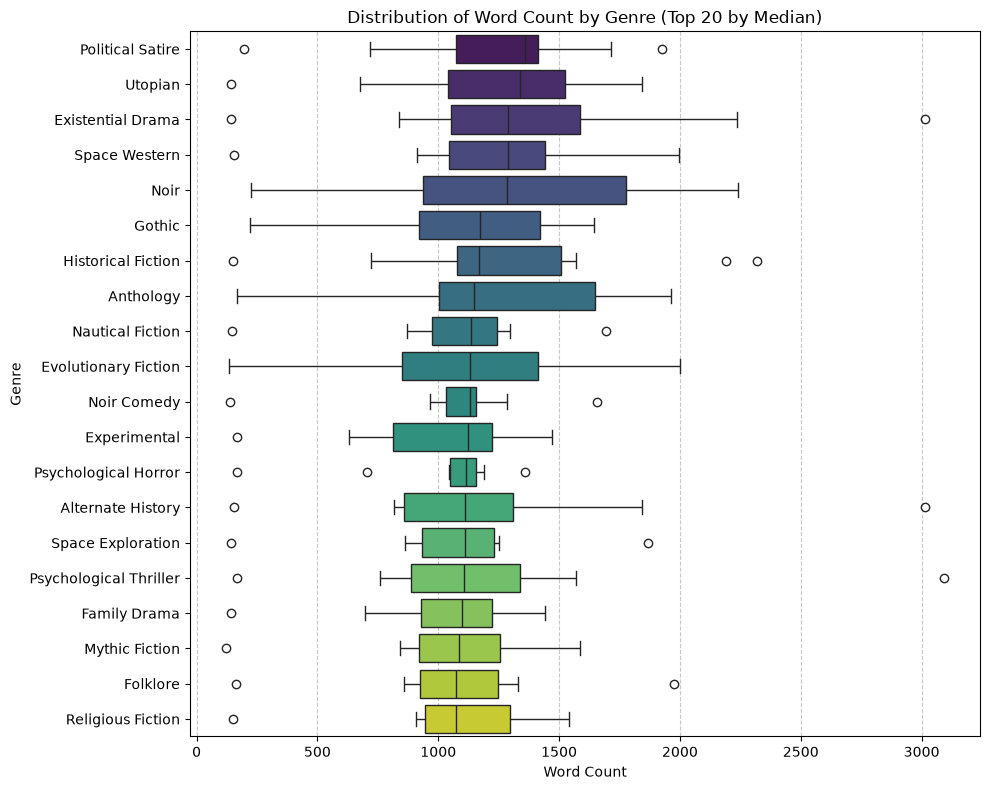

In [33]:
plt.figure(figsize=(10, 8))
sns.boxplot(
    data=df_top20,
    y="genre",
    x="word_count",
    order=top_20_genres,  
    palette="viridis",
)

plt.title("Distribution of Word Count by Genre (Top 20 by Median)")
plt.xlabel("Word Count")
plt.ylabel("Genre")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
sorted(df["genre"].unique())

['Adventure',
 'Alternate Dimension',
 'Alternate History',
 'Alternate Reality',
 'Animal Fantasy',
 'Animal Fiction',
 'Anthology',
 'Apocalyptic',
 'Apocalyptic Comedy',
 'Artificial Intelligence',
 'Artistic Drama',
 'Biographical',
 'Comedy',
 'Coming-of-Age',
 'Coming-of-Middle-Age',
 'Crime',
 'Cyberpunk',
 'Detective Fiction',
 'Disaster',
 'Domestic Fiction',
 'Dreamlike',
 'Dystopian',
 'Environmental',
 'Espionage',
 'Evolutionary Fiction',
 'Existential Drama',
 'Experimental',
 'Fairy Tale',
 'Family Drama',
 'Fantasy',
 'Folklore',
 'Futuristic',
 'Generation Gap',
 'Gothic',
 'Hard Science Fiction',
 'Historical Adventure',
 'Historical Fiction',
 'Historical Romance',
 'Horror',
 'Humor',
 'Inspirational',
 'Legal Drama',
 'Magical Girl',
 'Magical Realism',
 'Medical Drama',
 'Medical Mystery',
 'Military Fiction',
 'Multiverse',
 'Mystery',
 'Mystery Comedy',
 'Mystery Thriller',
 'Mythic Fiction',
 'Mythology',
 'Nautical Fiction',
 'Noir',
 'Noir Comedy',
 'Paranorm

# Titles

In [34]:
df["title"].nunique()

1000

In [35]:
df[["id", "title", "genre"]].sample(20)

,id,title,genre
62,735471,The Voyage of The Sea Serpent,Nautical Fiction
73,22214,The Enchanted Forest of Seraphina,Romantic Fantasy
219,989341,The Chronicles of The Vigilante,Superhero
255,106257,Quantum Horizons,Soft Science Fiction
660,651032,The Unseen Miracle,Religious Fiction
173,93842,A Dance with Destiny,Romantic Fantasy
484,687787,Leap of Cosmic Faith,Quantum Fiction
337,76133,The Journey of a Lifetime: The Untold Story of...,Biographical
564,172433,The Haunting of Windridge Manor,Psychological Horror
37,664632,The Chronicles of Jack Reynolds: A Life of Str...,Biographical


In [38]:
for _, row in df.sample(1, random_state=42).iterrows():
    print("=" * 80)
    print("ID:", row["id"])
    print("TITLE:", row["title"])
    print("GENRE:", row["genre"])
    print(row["story"][:2000])

ID: 189780
TITLE: The Enchanted Journey of Elara
GENRE: Magical Realism
Elara was a young and vivacious girl living in the small, serene town of Willow Creek. Life was a simple melody in her world; her days were filled with laughter, play, and the gentle rustling of leaves from the trees that lined the streets. Her parents, Maris and Lillian, were the kindest and most loving souls she had ever known, and her best friend, Amelia, was the perfect companion.

Elara's life took a magical turn when her twelfth birthday arrived. As she blew out the candles on her cake, she whispered a secret wish: "To uncover the hidden mysteries of Willow Creek and bring joy to all who live here."

Suddenly, a shimmering light filled the room, and a beautiful, ethereal being appeared before her. This enchanting being was none other than the spirit of the town, Willow. She revealed to Elara that the town was home to an ancient, magical force that had been dormant for centuries. Elara was chosen to awaken thi